# Latent Sentiment BBN — Pipeline Benchmark Notebook

This notebook consolidates the production-style Bayesian belief network pipeline in **latent-sentiment-bbn**: data contract, constrained structure learning, EM parameter fitting, held-out evaluation against discriminative baselines, calibration diagnostics, and serving-time inference latency.

**Prerequisites** (from repo root):

```bash
uv sync --all-groups
uv run python scripts/clean_data.py --skip-inspect   # if data/clean_leads.parquet is missing
uv run python -m models.train                        # writes src/models/artifacts/*
```

Set `RETRAIN = True` below to rerun structure learning + EM inside the notebook (several minutes on ~1k rows).


In [8]:
from __future__ import annotations

import json
import pickle
import time
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from IPython.display import Markdown, display

from models.baselines import (
    RANDOM_FOREST_BASELINE,
    XGBOOST_BASELINE,
    predict_all_baselines,
    train_discriminative_baselines,
)
from models.discretization import load_discretization_config
from models.feature_contract import DEFAULT_FEATURE_CONTRACT, TARGET_COLUMN
from models.inference import build_lead_frame, score_lead
from models.splits import TEST_SPLIT, VALIDATION_SPLIT
from models.structure import LATENT_NODE
from models.train import (
    load_cleaned_leads,
    prepare_temporal_modeling_frames,
    train_model,
)
from models.validation import evaluate_model_comparison, predict_probabilities

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)

# Resolve repo root whether the kernel cwd is repo root or notebooks/
_cwd = Path.cwd()
PROJECT_ROOT = _cwd if (_cwd / "pyproject.toml").exists() else _cwd.parent
from models.train import ARTIFACT_PATH, METADATA_PATH as TRAIN_METADATA_PATH

ARTIFACT_DIR = ARTIFACT_PATH.parent
MODEL_PATH = ARTIFACT_PATH
METADATA_PATH = TRAIN_METADATA_PATH
VALIDATION_PATH = ARTIFACT_DIR / "model_validation.json"
DISCRETIZATION_PATH = ARTIFACT_DIR / "discretization_config.json"
CLEAN_LEADS_PATH = PROJECT_ROOT / "data" / "clean_leads.parquet"

RETRAIN = False  # flip to True to rerun hill-climb + EM in-notebook

print(f"Project root: {PROJECT_ROOT}")
print(f"Artifacts:    {ARTIFACT_DIR}")


Project root: /home/jackreed/BBN/latent-sentiment-bbn
Artifacts:    /home/jackreed/BBN/latent-sentiment-bbn/src/models/artifacts


## 1. Design flow (end-to-end)

The system mirrors an enterprise lead-scoring stack: synthetic/raw warehouse → dbt marts → Polars cleaning → **leakage-aware temporal splits** → discretization fit on train only → **constrained hill-climb (BIC)** on observed nodes → insert hidden `latent_sentiment` → **EM CPT fitting** → serialized `model.pkl` → FastAPI variable elimination at score time.

Run the next cell for an inline **butterfly layout** (ingest on the left wing, modeling down the spine, evaluation and serving on the right).

### Modeling choices 

| Stage | What we do | Why |
|-------|------------|-----|
| Feature contract | Lead-capture evidence only (`web_session_band`, firmographics, channel) | Avoids post-outcome leakage (`replied_within_7d`, `lead_score`) at score time |
| Structure search | Whitelist edges + `max_indegree=3`, score with BIC | Causal plausibility + parsimony on small data |
| Latent node | `latent_sentiment` → signals + conversion | True sentiment is unobserved in production data |
| Parameters | EM with smoothing | Estimates hidden CPTs without latent labels |
| Metrics | Log loss, Brier, ROC/PR AUC, calibration bins | Posterior probabilities are the product, not just ranking |
| Baselines | One-hot + Random Forest / XGBoost on same frame | Same features, different inductive bias |


In [ ]:
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch


def plot_pipeline_butterfly(*, ax: plt.Axes | None = None) -> plt.Axes:
    """Pipeline DAG in a butterfly layout: ingest (left), ML spine (center), eval/serve (right)."""
    stage_colors = {
        "Ingest": "#4C78A8",
        "Modeling": "#F58518",
        "Evaluation": "#54A24B",
        "Serving": "#E45756",
    }
    # label, stage, x, y
    nodes: dict[str, tuple[str, str, float, float]] = {
        "RAW": ("raw_leads.duckdb", "Ingest", -3.1, 1.2),
        "DBT": ("dbt_pipeline", "Ingest", -2.3, 0.55),
        "CLEAN": ("clean_leads.parquet", "Ingest", -1.5, -0.1),
        "SPLIT": ("temporal splits", "Modeling", -0.15, 0.95),
        "DISC": ("discretization\n(train only)", "Modeling", 0.15, 0.45),
        "HC": ("hill-climb + BIC", "Modeling", 0.45, -0.05),
        "LAT": ("+ latent_sentiment", "Modeling", 0.75, -0.55),
        "EM": ("EM parameter fit", "Modeling", 1.05, -1.05),
        "PKL": ("model.pkl", "Modeling", 1.35, -1.55),
        "VAL": ("held-out metrics", "Evaluation", 2.55, 0.75),
        "BASE": ("RF + XGBoost", "Evaluation", 2.55, 0.05),
        "RPT": ("model_validation.json", "Evaluation", 3.35, 0.4),
        "API": ("FastAPI /predict", "Serving", 2.55, -1.35),
        "VE": ("VariableElimination", "Serving", 3.35, -1.35),
    }
    edges = [
        ("RAW", "DBT"),
        ("DBT", "CLEAN"),
        ("CLEAN", "SPLIT"),
        ("SPLIT", "DISC"),
        ("DISC", "HC"),
        ("HC", "LAT"),
        ("LAT", "EM"),
        ("EM", "PKL"),
        ("EM", "VAL"),
        ("EM", "BASE"),
        ("VAL", "RPT"),
        ("PKL", "API"),
        ("API", "VE"),
    ]

    if ax is None:
        _, ax = plt.subplots(figsize=(12, 4.8))
    ax.set_axis_off()
    ax.set_xlim(-4.0, 4.2)
    ax.set_ylim(-2.2, 1.8)
    ax.set_title(
        "Latent Sentiment BBN — end-to-end pipeline (butterfly layout)",
        fontsize=12,
        pad=10,
    )

    def box_edge(key: str, toward: str) -> tuple[float, float]:
        _, _, x, y = nodes[key]
        tx, ty = nodes[toward][2], nodes[toward][3]
        dx, dy = tx - x, ty - y
        length = (dx**2 + dy**2) ** 0.5 or 1.0
        return x + 0.58 * dx / length, y + 0.24 * dy / length

    for key, (label, stage, x, y) in nodes.items():
        patch = FancyBboxPatch(
            (x - 0.62, y - 0.28),
            1.24,
            0.56,
            boxstyle="round,pad=0.02,rounding_size=0.06",
            linewidth=1.0,
            edgecolor="white",
            facecolor=stage_colors[stage],
            alpha=0.93,
            zorder=2,
        )
        ax.add_patch(patch)
        ax.text(
            x,
            y,
            label,
            ha="center",
            va="center",
            fontsize=7.5,
            color="white",
            fontweight="bold",
            zorder=3,
        )

    for parent, child in edges:
        start = box_edge(parent, child)
        end = box_edge(child, parent)
        ax.add_patch(
            FancyArrowPatch(
                start,
                end,
                arrowstyle="-|>",
                mutation_scale=12,
                linewidth=1.2,
                color="#555555",
                connectionstyle="arc3,rad=0.08",
                zorder=1,
            )
        )

    handles = [
        plt.Line2D([0], [0], marker="s", color="w", markerfacecolor=color, markersize=10, label=stage)
        for stage, color in stage_colors.items()
    ]
    ax.legend(handles=handles, loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.02))
    return ax


plot_pipeline_butterfly()
plt.tight_layout()
plt.show()

## 2. Load or train artifacts


In [3]:
def load_training_bundle(*, retrain: bool = RETRAIN):
    if retrain or not MODEL_PATH.exists():
        if not CLEAN_LEADS_PATH.exists():
            raise FileNotFoundError(
                f"Missing {CLEAN_LEADS_PATH}. Run clean_data.py first."
            )
        cleaned = load_cleaned_leads(CLEAN_LEADS_PATH)
        frames = prepare_temporal_modeling_frames(cleaned)
        result = train_model(frames.train)
        baselines = train_discriminative_baselines(frames.train)
        heldout = {
            VALIDATION_SPLIT: frames.validation,
            TEST_SPLIT: frames.test,
        }
        baseline_predictions = {name: {} for name in baselines}
        for split_name, frame in heldout.items():
            for model_name, preds in predict_all_baselines(baselines, frame).items():
                baseline_predictions[model_name][split_name] = preds
        report = evaluate_model_comparison(
            result.model,
            baseline_predictions,
            heldout,
            result.constraints,
        )
        with MODEL_PATH.open("wb") as handle:
            pickle.dump(result.model, handle)
        return result.model, report, frames, result.bic_score

    with MODEL_PATH.open("rb") as handle:
        model = pickle.load(handle)
    report_payload = json.loads(VALIDATION_PATH.read_text()) if VALIDATION_PATH.exists() else None
    frames = None
    bic_score = None
    if METADATA_PATH.exists():
        meta = json.loads(METADATA_PATH.read_text())
        bic_score = meta.get("bic_score")
    if CLEAN_LEADS_PATH.exists():
        frames = prepare_temporal_modeling_frames(load_cleaned_leads(CLEAN_LEADS_PATH))
    return model, report_payload, frames, bic_score


model, validation_payload, modeling_frames, bic_score = load_training_bundle()
metadata = json.loads(METADATA_PATH.read_text()) if METADATA_PATH.exists() else {}

display(Markdown(f"**BIC (observed DAG):** `{bic_score}`"))
display(Markdown("**Temporal split counts:**"))
display(pd.Series(metadata.get("split_counts", {}), name="rows"))
display(Markdown("**Learned observed edges:**"))
display(pd.DataFrame(metadata.get("learned_observed_edges", []), columns=["parent", "child"]))
display(Markdown("**Fixed latent edges:**"))
display(pd.DataFrame(metadata.get("latent_edges", []), columns=["parent", "child"]))


**BIC (observed DAG):** `-7530.885064296221`

**Temporal split counts:**

validation                    147
excluded_missing_timestamp     16
train                         688
test                          149
Name: rows, dtype: int64

**Learned observed edges:**

,parent,child
0,web_session_band,demo_requested_bool


**Fixed latent edges:**

,parent,child
0,latent_sentiment,demo_requested_bool
1,latent_sentiment,web_session_band


## 3. Graph structure (learned + expert latent edges)


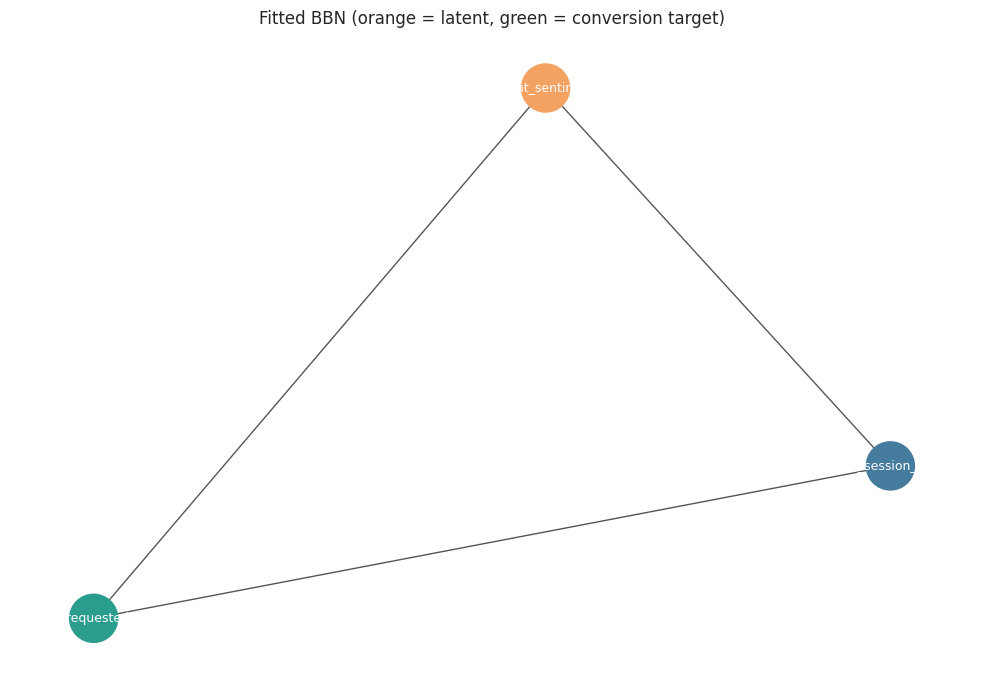

,is_acyclic,model_check_passed,node_count,edge_count,latent_node_present,honors_forbidden_edges,forbidden_edges_present,missing_latent_edges
0,True,True,8,3,True,True,[],[]


,cpd_count,near_deterministic_cpds,invalid_probability_cpds,has_invalid_probabilities
0,8,[],[],False


In [4]:
fig, ax = plt.subplots(figsize=(10, 7))
graph = nx.DiGraph()
graph.add_edges_from(model.edges())

pos = nx.spring_layout(graph, seed=42)
node_colors = ["#f4a261" if node == LATENT_NODE else "#2a9d8f" if node == TARGET_COLUMN else "#457b9d" for node in graph.nodes]
nx.draw_networkx_nodes(graph, pos, node_color=node_colors, node_size=1200, ax=ax)
nx.draw_networkx_labels(graph, pos, font_size=9, font_color="white", ax=ax)
nx.draw_networkx_edges(graph, pos, edge_color="#555", arrows=True, arrowsize=16, ax=ax)
ax.set_title("Fitted BBN (orange = latent, green = conversion target)")
ax.axis("off")
plt.tight_layout()
plt.show()

structure_checks = (validation_payload or {}).get("structure", {})
cpt_checks = (validation_payload or {}).get("cpt_checks", {})
display(pd.DataFrame([structure_checks]))
display(pd.DataFrame([cpt_checks]))


## 4. Comparative metrics vs baselines

Metrics are computed on **held-out temporal splits** (validation + test). Probabilistic quality uses **log loss** and **Brier score**; ranking uses **ROC AUC** and **PR AUC**. Threshold metrics at 0.5 are reported for completeness but are secondary for calibrated posteriors.


### Split: `validation`

,rows,base_rate,log_loss,brier_score,roc_auc,pr_auc,accuracy_at_0_5,f1_at_0_5
model,,,,,,,,
bbn,147,0.4286,0.6485,0.2282,0.6623,0.5912,0.6395,0.6294
random_forest,147,0.4286,0.6608,0.2342,0.6306,0.5232,0.6327,0.5424
xgboost,147,0.4286,0.6882,0.2464,0.5928,0.4980,0.6054,0.5469


### Split: `test`

,rows,base_rate,log_loss,brier_score,roc_auc,pr_auc,accuracy_at_0_5,f1_at_0_5
model,,,,,,,,
bbn,149,0.4295,0.7099,0.2581,0.4833,0.4313,0.4631,0.4030
random_forest,149,0.4295,0.7102,0.2579,0.4846,0.4131,0.5168,0.3898
xgboost,149,0.4295,0.7368,0.2698,0.4947,0.4304,0.5168,0.4286


### Best model per metric (saved report)

,accuracy_at_0_5,brier_score,f1_at_0_5,log_loss,pr_auc,roc_auc
validation,"{'model': 'bbn', 'value': 0.6394557823129252}","{'model': 'bbn', 'value': 0.22819396647169196}","{'model': 'bbn', 'value': 0.6293706293706294}","{'model': 'bbn', 'value': 0.6485430558279814}","{'model': 'bbn', 'value': 0.5911524590701279}","{'model': 'bbn', 'value': 0.6623204837490552}"
test,"{'model': 'random_forest', 'value': 0.51677852...","{'model': 'random_forest', 'value': 0.25792829...","{'model': 'xgboost', 'value': 0.42857142857142...","{'model': 'bbn', 'value': 0.7099374193536991}","{'model': 'bbn', 'value': 0.4312741566410375}","{'model': 'xgboost', 'value': 0.49466911764705..."


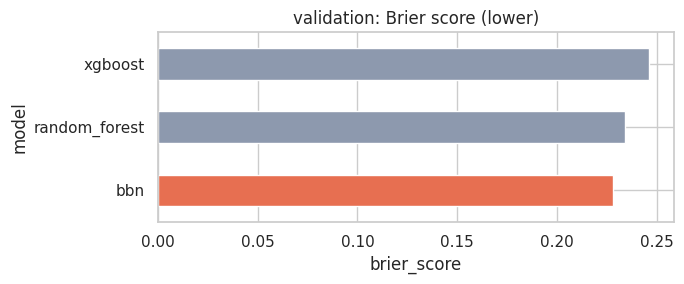

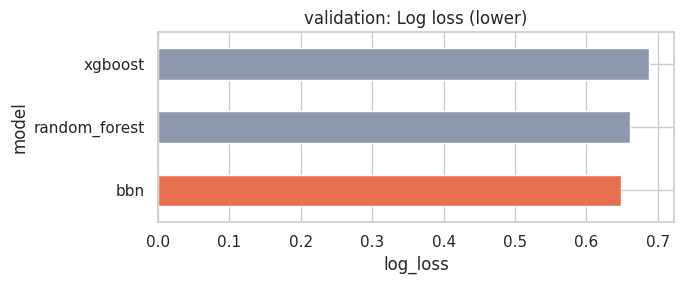

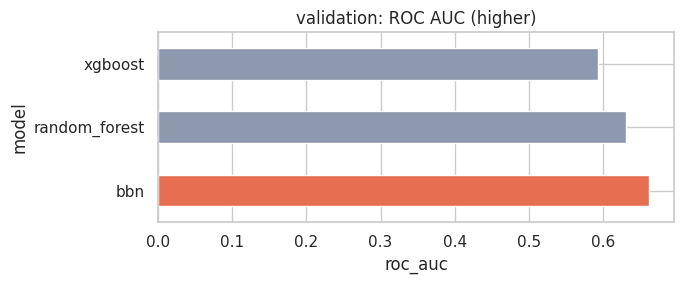

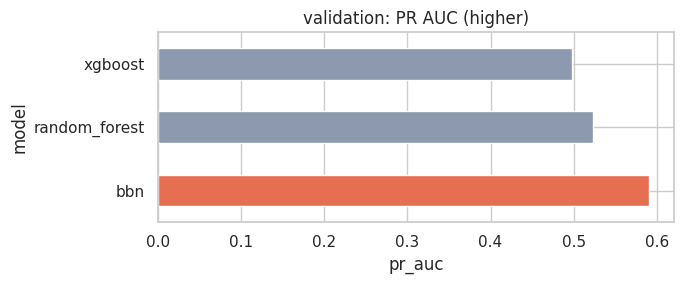

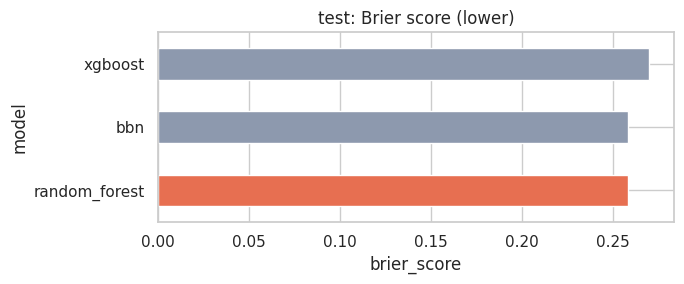

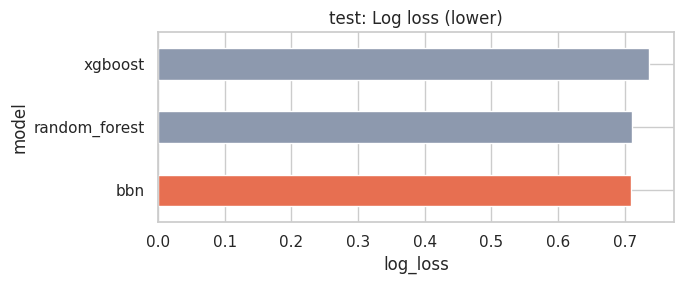

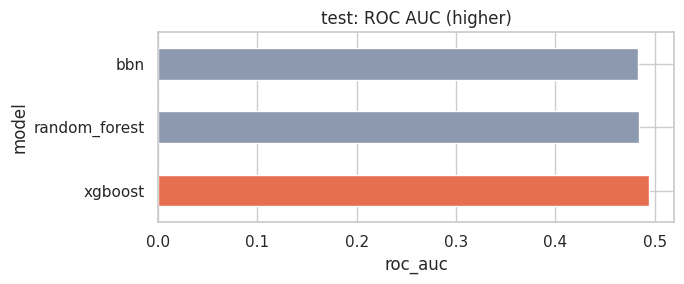

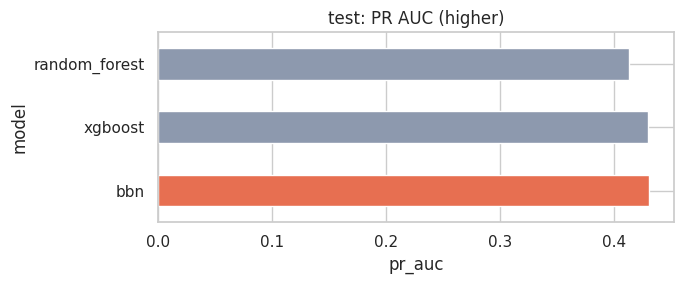

In [5]:
METRIC_LABELS = {
    "log_loss": "Log loss (lower)",
    "brier_score": "Brier score (lower)",
    "roc_auc": "ROC AUC (higher)",
    "pr_auc": "PR AUC (higher)",
    "accuracy_at_0_5": "Accuracy @0.5",
    "f1_at_0_5": "F1 @0.5",
}


def metrics_table(payload: dict, split_name: str) -> pd.DataFrame:
    split_block = payload["splits"][split_name]
    rows = []
    for model_name, result in split_block.items():
        row = {"model": model_name, "rows": result["row_count"], "base_rate": result["target_prevalence"]}
        row.update(result["metrics"])
        rows.append(row)
    return pd.DataFrame(rows).set_index("model")


def plot_metric_bars(payload: dict, split_name: str, metric: str) -> None:
    table = metrics_table(payload, split_name)
    values = table[metric].dropna()
    colors = ["#e76f51" if name == "bbn" else "#8d99ae" for name in values.index]
    ax = values.sort_values(ascending=metric in {"log_loss", "brier_score"}).plot(
        kind="barh", color=colors, figsize=(7, 3), title=f"{split_name}: {METRIC_LABELS.get(metric, metric)}"
    )
    ax.set_xlabel(metric)
    plt.tight_layout()
    plt.show()


if validation_payload is None:
  print("No saved validation report; set RETRAIN=True to compute metrics.")
else:
    for split_name in ("validation", "test"):
        display(Markdown(f"### Split: `{split_name}`"))
        display(metrics_table(validation_payload, split_name).round(4))
    summary = pd.DataFrame(validation_payload.get("comparison_summary", {})).T
    display(Markdown("### Best model per metric (saved report)"))
    display(summary)

    for split_name in ("validation", "test"):
        for metric in ("brier_score", "log_loss", "roc_auc", "pr_auc"):
            plot_metric_bars(validation_payload, split_name, metric)


## 5. Probability calibration

Calibration bins group predictions by **equal-width** probability bands (see `models.validation.calibration_bins`). A well-calibrated model has `observed_rate ≈ mean_predicted` along the diagonal. Tree baselines often rank well but can be miscalibrated without post-hoc scaling — exactly why we track Brier/log loss for the BBN product.


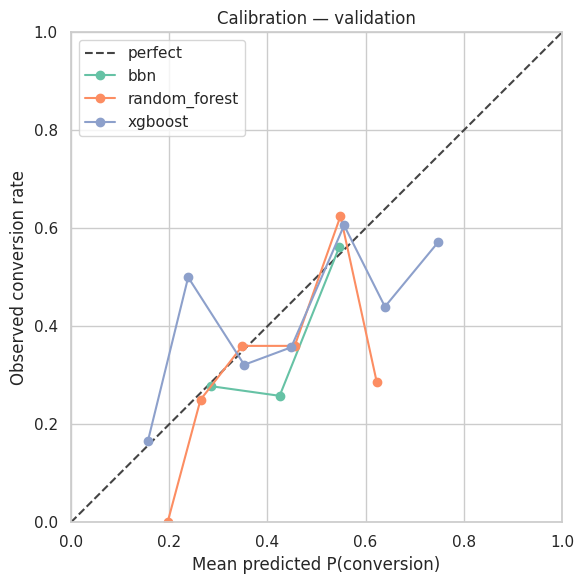

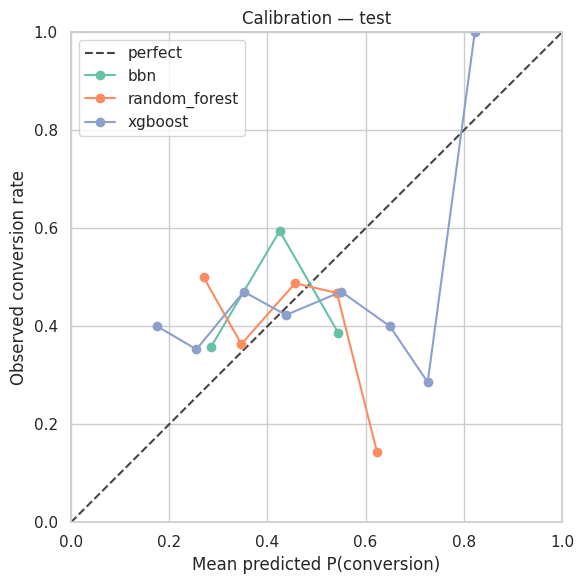

In [6]:
def plot_calibration_curves(payload: dict, split_name: str, models: list[str] | None = None) -> None:
    split_block = payload["splits"][split_name]
    model_names = models or list(split_block.keys())
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot([0, 1], [0, 1], linestyle="--", color="#444", label="perfect")
    palette = sns.color_palette("Set2", n_colors=len(model_names))
    for color, model_name in zip(palette, model_names, strict=True):
        bins = split_block[model_name]["calibration_bins"]
        xs, ys = [], []
        for band in bins:
            if band["count"] and band["mean_predicted"] is not None and band["observed_rate"] is not None:
                xs.append(band["mean_predicted"])
                ys.append(band["observed_rate"])
        if xs:
            ax.plot(xs, ys, marker="o", label=model_name, color=color)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Mean predicted P(conversion)")
    ax.set_ylabel("Observed conversion rate")
    ax.set_title(f"Calibration — {split_name}")
    ax.legend()
    plt.tight_layout()
    plt.show()


if validation_payload is not None:
    for split_name in ("validation", "test"):
        plot_calibration_curves(validation_payload, split_name)


## 6. Inference performance

Serving loads `model.pkl` once (FastAPI lifespan) and runs **pgmpy Variable Elimination** per lead. Batch scoring in validation reuses one `VariableElimination` instance per split but still queries row-by-row — this section quantifies that cost and contrasts API-style single-lead scoring via `score_lead`.


In [7]:
if modeling_frames is None:
    print("Skipping live benchmarks — clean_leads.parquet not found.")
else:
    test_frame = modeling_frames.test
    sample_n = min(50, len(test_frame))
    sample_frame = test_frame.head(sample_n)

    # Batch path used in validation.py
    t0 = time.perf_counter()
    batch_probs, batch_warnings = predict_probabilities(model, sample_frame)
    batch_elapsed = time.perf_counter() - t0

    # Serving path (discretization + evidence contract)
    disc_config = load_discretization_config(DISCRETIZATION_PATH)
    example_lead = {
        "domain": "acme.example",
        "marketing_channel": "paid_search",
        "campaign_tier": "tier1_enterprise",
        "region": "NA",
        "company_size": "mid_market",
        "job_title": "Director of Marketing",
        "web_session_seconds": 420.0,
    }
    lead_frame = build_lead_frame(example_lead)

    single_timings_ms = []
    for _ in range(200):
        t0 = time.perf_counter()
        score_lead(model, example_lead, disc_config)
        single_timings_ms.append((time.perf_counter() - t0) * 1000)

    perf = pd.DataFrame(
        {
            "scenario": [
                f"validation batch ({sample_n} rows)",
                "API score_lead (median of 200)",
                "API score_lead (p95 of 200)",
            ],
            "milliseconds": [
                batch_elapsed * 1000,
                float(np.median(single_timings_ms)),
                float(np.percentile(single_timings_ms, 95)),
            ],
            "per_lead_ms": [
                batch_elapsed / sample_n * 1000,
                float(np.median(single_timings_ms)),
                float(np.percentile(single_timings_ms, 95)),
            ],
        }
    )
    display(perf.round(3))
    if batch_warnings:
        display(Markdown("**Evidence warnings (unsupported states skipped):**"))
        display(pd.Series(batch_warnings).value_counts().head())

    result = score_lead(model, example_lead, disc_config)
    display(Markdown(
        f"Example posterior P(`{TARGET_COLUMN}`=true) = **{result.posterior_conversion_probability:.3f}**"
    ))
    display(pd.Series(result.evidence_used, name="evidence"))


,scenario,milliseconds,per_lead_ms
0,validation batch (50 rows),50.259,1.005
1,API score_lead (median of 200),2.655,2.655
2,API score_lead (p95 of 200),3.413,3.413


Example posterior P(`demo_requested_bool`=true) = **0.515**

marketing_channel_clean              paid_search
campaign_tier_clean             tier1_enterprise
region_clean                                  NA
employee_size_bucket                  mid_market
job_title_clean            director of marketing
web_session_band                         engaged
Name: evidence, dtype: str

## 7. Takeaways

1. **Design**: Constrained structure learning encodes marketing plausibility; the latent node captures unobserved sentiment without leaking `True_Consumer_Sentiment` from synthetic generation.
2. **Benchmarks**: Compare Brier/log loss first (calibrated probability), then ROC/PR AUC (ranking). On this snapshot, check the saved `comparison_summary` — no single model wins every metric on every split.
3. **Calibration**: Inspect reliability curves; narrow predicted bands on small data are common — widen bins or use isotonic scaling if production requires tighter calibration.
4. **Serving**: Sub-10ms per lead is typical for this graph size; batch training-time scoring is dominated by Python row loops, not VE complexity.
5. **Next steps**: Regenerate with 50k rows (`generate_raw_leads.py` + dbt + clean), tune `StructureLearningConfig.show_progress=False` for notebooks, and wire enrichment paths from `src/api/services.py` when `employee_size_bucket` is missing.
